In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore

# Load CSV  for benin-malanville
df = pd.read_csv("../data/togo-dapaong_qc.csv")
print("Shape:", df.shape)
print(df.info())
print(df.describe())
print(df.isna().sum())
# Only fill NaN for numeric columns
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# If you want to drop columns that are all NaN, like 'Comments':

Shape: (525295, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525295 entries, 0 to 525294
Data columns (total 18 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Timestamp      525295 non-null  object 
 1   GHI            525295 non-null  float64
 2   DNI            525295 non-null  float64
 3   DHI            525295 non-null  float64
 4   ModA           525295 non-null  float64
 5   ModB           525295 non-null  float64
 6   Tamb           525295 non-null  float64
 7   RH             525295 non-null  float64
 8   WS             525295 non-null  float64
 9   WSgust         525295 non-null  float64
 10  WSstdev        525295 non-null  float64
 11  WD             525295 non-null  float64
 12  WDstdev        525295 non-null  float64
 13  BP             525295 non-null  int64  
 14  Cleaning       525295 non-null  int64  
 15  Precipitation  525295 non-null  float64
 16  TModA          525295 non-null  float64
 17  TModB    

In [13]:
# 5️⃣ Detect outliers
df['z_GHI'] = zscore(df['GHI'])
df = df[df['z_GHI'].abs() < 3]
print(df)
df.drop(columns=['z_GHI'], inplace=True)


                  Timestamp  GHI  DNI  DHI  ModA  ModB  Tamb    RH   WS  \
0       2021-10-25 00:01:00 -1.3  0.0  0.0   0.0   0.0  24.8  94.5  0.9   
1       2021-10-25 00:02:00 -1.3  0.0  0.0   0.0   0.0  24.8  94.4  1.1   
2       2021-10-25 00:03:00 -1.3  0.0  0.0   0.0   0.0  24.8  94.4  1.2   
3       2021-10-25 00:04:00 -1.2  0.0  0.0   0.0   0.0  24.8  94.3  1.2   
4       2021-10-25 00:05:00 -1.2  0.0  0.0   0.0   0.0  24.8  94.0  1.3   
...                     ...  ...  ...  ...   ...   ...   ...   ...  ...   
525290  2022-10-24 23:56:00 -0.8  0.0  0.0   0.0   0.0  25.2  53.8  0.0   
525291  2022-10-24 23:57:00 -0.9  0.0  0.0   0.0   0.0  25.3  53.5  0.0   
525292  2022-10-24 23:58:00 -1.0  0.0  0.0   0.0   0.0  25.3  53.4  0.0   
525293  2022-10-24 23:59:00 -1.1  0.0  0.0   0.0   0.0  25.4  53.5  0.0   
525294  2022-10-25 00:00:00 -1.2  0.0  0.0   0.0   0.0  25.4  52.3  0.0   

        WSgust  WSstdev     WD  WDstdev   BP  Cleaning  Precipitation  TModA  \
0          1.1     

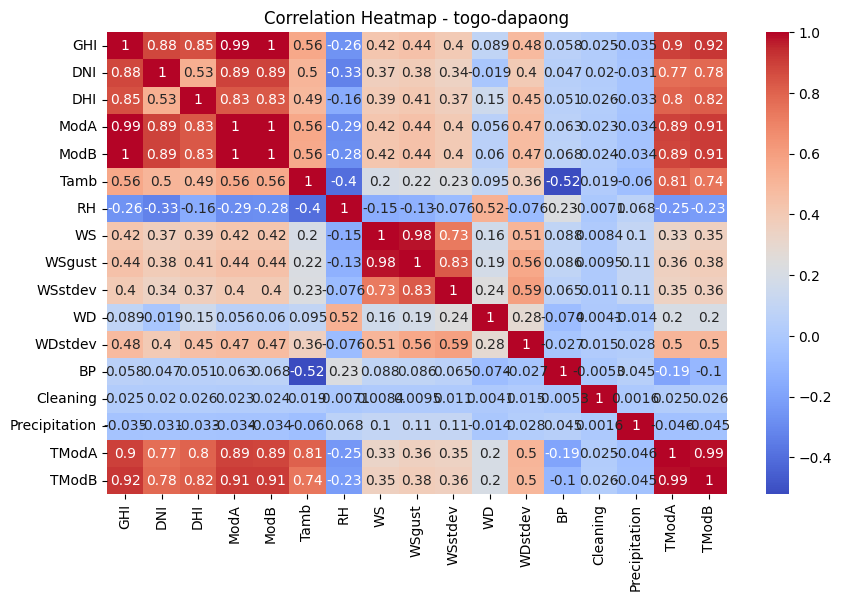

                    GHI       DNI       DHI      ModA      ModB      Tamb  \
GHI            1.000000  0.876921  0.851590  0.994948  0.995420  0.563630   
DNI            0.876921  1.000000  0.531238  0.889351  0.889367  0.504948   
DHI            0.851590  0.531238  1.000000  0.832456  0.832068  0.490233   
ModA           0.994948  0.889351  0.832456  1.000000  0.999562  0.562063   
ModB           0.995420  0.889367  0.832068  0.999562  1.000000  0.557122   
Tamb           0.563630  0.504948  0.490233  0.562063  0.557122  1.000000   
RH            -0.259881 -0.329267 -0.156093 -0.288791 -0.281860 -0.400523   
WS             0.421793  0.366461  0.390408  0.420382  0.421608  0.197110   
WSgust         0.444010  0.384642  0.410317  0.442590  0.443624  0.221065   
WSstdev        0.399660  0.343179  0.366758  0.398520  0.398960  0.227070   
WD             0.088850 -0.018983  0.153369  0.056066  0.059994  0.094770   
WDstdev        0.479464  0.397255  0.454240  0.472602  0.472208  0.361336   

In [14]:
# Select only numeric columns for the correlation heatmap
numeric_cols = df.select_dtypes(include=['float64', 'int64'])
plt.figure(figsize=(10,6))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap - togo-dapaong')
plt.show()
# Get and print the full correlation matrix for all numeric columns
corr_matrix = numeric_cols.corr()
print(corr_matrix)

In [15]:
# Get numeric correlation matrix
corr_matrix = numeric_cols.corr()

# Calculate average absolute correlation for each variable (excluding self, the diagonal)
average_corr = corr_matrix.apply(lambda row: (row.drop(row.name).abs().mean()), axis=1)
print(average_corr)


GHI              0.519499
DNI              0.448645
DHI              0.450137
ModA             0.516980
ModB             0.516875
Tamb             0.395470
RH               0.215017
WS               0.351121
WSgust           0.373176
WSstdev          0.342927
WD               0.147192
WDstdev          0.358018
BP               0.107173
Cleaning         0.015609
Precipitation    0.049301
TModA            0.516820
TModB            0.515691
dtype: float64


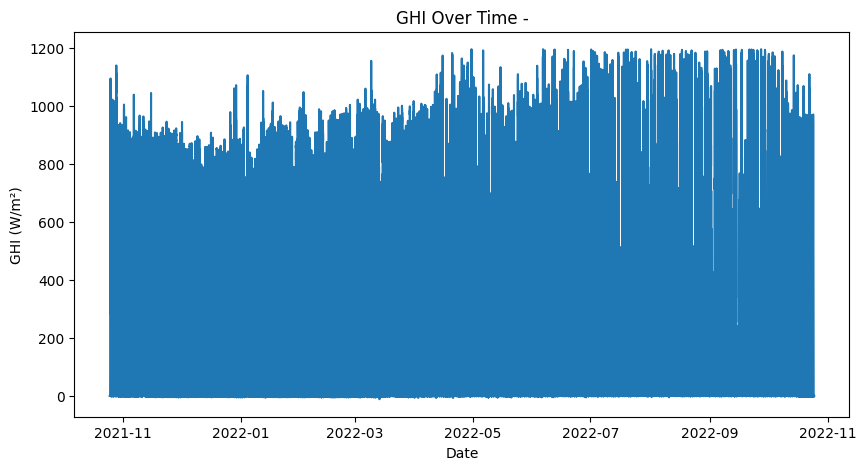

In [16]:
# 8️⃣ Plot GHI over time
plt.figure(figsize=(10,5))
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
plt.plot(df['Timestamp'], df['GHI'])
plt.title('GHI Over Time -')
plt.xlabel('Date')
plt.ylabel('GHI (W/m²)')
plt.show()


In [17]:

# 9️⃣ Export cleaned data
df.to_csv('../data/togo-dapaong_qc.csv', index=False)

In [18]:
import pandas as pd
from scipy.stats import zscore
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load your dataset
df = pd.read_csv("../data/togo-dapaong_qc.csv")

# --- STEP 1: Basic checks ---
print("Shape before cleaning:", df.shape)
print("Columns:", df.columns.tolist())
print(df.head(3))

# --- STEP 2: Handle missing values ---
missing = df.isna().sum()
print("\nMissing values before cleaning:\n", missing[missing > 0])

# Fill missing numeric values with median
df.fillna(df.median(numeric_only=True), inplace=True)

# --- STEP 3: Outlier removal for GHI (if exists) ---
if "GHI" in df.columns:
    df['z_GHI'] = zscore(df['GHI'])
    df = df[df['z_GHI'].abs() < 3]
    df.drop(columns=['z_GHI'], inplace=True)
else:
    print("⚠️ Warning: Column 'GHI' not found — skipping outlier cleaning.")

# --- STEP 4: Save cleaned file ---
output_path = "../data/togo_clean.csv"
df.to_csv(output_path, index=False)
print(f"\n✅ Cleaned data saved successfully as {output_path}")
print("Shape after cleaning:", df.shape)


Shape before cleaning: (525282, 18)
Columns: ['Timestamp', 'GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'Tamb', 'RH', 'WS', 'WSgust', 'WSstdev', 'WD', 'WDstdev', 'BP', 'Cleaning', 'Precipitation', 'TModA', 'TModB']
             Timestamp  GHI  DNI  DHI  ModA  ModB  Tamb    RH   WS  WSgust  \
0  2021-10-25 00:01:00 -1.3  0.0  0.0   0.0   0.0  24.8  94.5  0.9     1.1   
1  2021-10-25 00:02:00 -1.3  0.0  0.0   0.0   0.0  24.8  94.4  1.1     1.6   
2  2021-10-25 00:03:00 -1.3  0.0  0.0   0.0   0.0  24.8  94.4  1.2     1.4   

   WSstdev     WD  WDstdev   BP  Cleaning  Precipitation  TModA  TModB  
0      0.4  227.6      1.1  977         0            0.0   24.7   24.4  
1      0.4  229.3      0.7  977         0            0.0   24.7   24.4  
2      0.3  228.5      2.9  977         0            0.0   24.7   24.4  

Missing values before cleaning:
 Series([], dtype: int64)

✅ Cleaned data saved successfully as ../data/togo_clean.csv
Shape after cleaning: (525278, 18)
